In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../DATA/CO2_Emissions.csv')

In [3]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


## Пояснение к Данным:
    1. Make - марка
    2. Model - модель
    3. Vehicle Class - класс/тип кузова машины
    4. Engine Size(L) - объем двигателя в литрах
    5. Cylinders - цилиндры в двигателе
    6. Transmission - тип коробки передач
    7. Fuel Type - тип топлива (Z - премиум бензин, X - обычный бензин, D - дизель, E - этанол)
    8. Fuel Consumption City (L/100 km) - расход топлива при езде по городу 100 км
    9. Fuel Consumption Hwy (L/100 km) - расход топлива на шоссе 100 км
    10. Fuel Consumption Comb (L/100 km) - комбинированный расход топлива 100 км
    11. Fuel Consumption Comb (mpg) - то эе что и 10, но в американской форме miles per galon
    12. CO2 Emissions(g/km) - таргет, выбросы газа

## ВСЯ РАБОТА

In [4]:
df = df.drop('Fuel Consumption Comb (mpg)', axis=1)

In [5]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,244


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: float64(4), int64(2), object(5)
memory usage: 634.8+ KB


In [7]:
df.duplicated().sum()

np.int64(1103)

In [8]:
df = df.drop_duplicates()

In [9]:
df = df.reset_index(drop=True)

In [10]:
df = df.drop(['Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)'], axis=1)

In [11]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,8.5,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,9.6,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,5.9,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,11.1,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,10.6,244


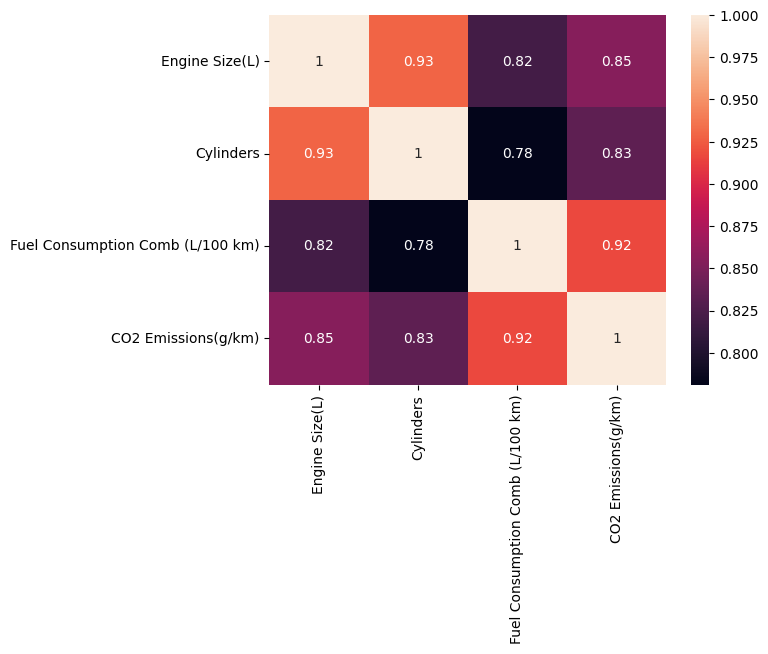

In [12]:
sns.heatmap(df.corr(numeric_only=True), annot=True);

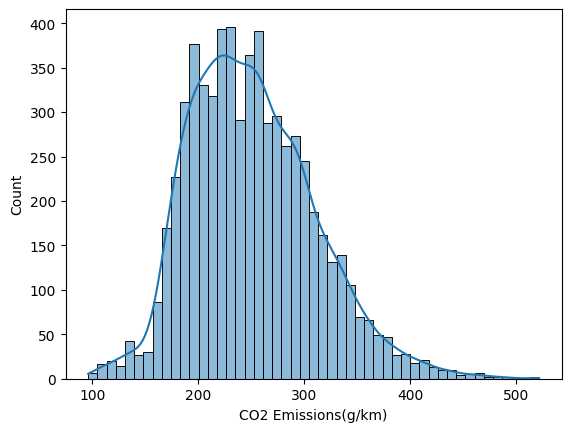

In [13]:
sns.histplot(df['CO2 Emissions(g/km)'], kde=True);

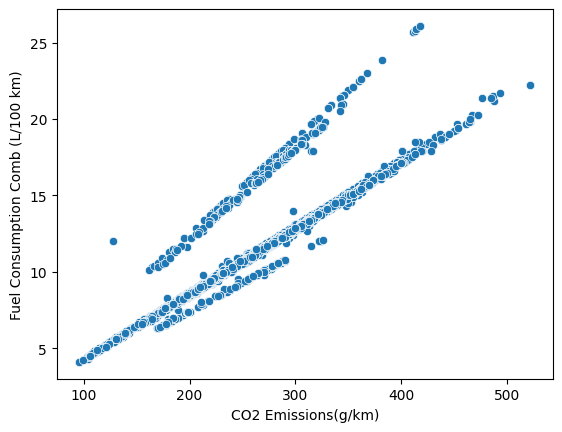

In [14]:
sns.scatterplot(x='CO2 Emissions(g/km)', y='Fuel Consumption Comb (L/100 km)', data=df);

In [15]:
df[(df['CO2 Emissions(g/km)'] < 150) & (df['Fuel Consumption Comb (L/100 km)'] > 10)]

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
3817,MERCEDES-BENZ,GLA 250 4MATIC,SUV - SMALL,2.0,4,AS7,E,12.0,128


In [16]:
df = df.drop(3817)

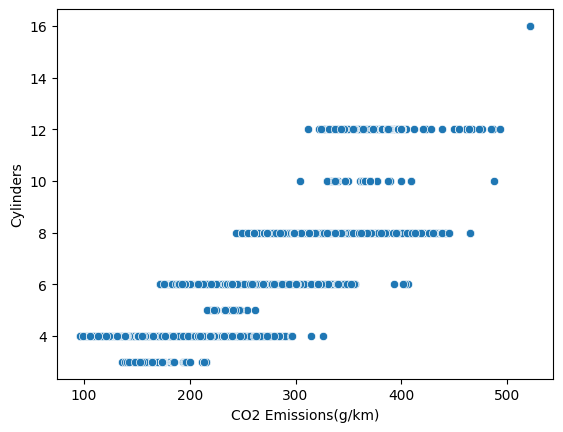

In [17]:
sns.scatterplot(x='CO2 Emissions(g/km)', y='Cylinders', data=df);

In [18]:
df[df['Cylinders'] == 16]

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
4199,BUGATTI,CHIRON,TWO-SEATER,8.0,16,AM7,Z,22.2,522
4897,BUGATTI,Chiron,TWO-SEATER,8.0,16,AM7,Z,22.2,522


In [19]:
df = df.drop([4199, 4897])

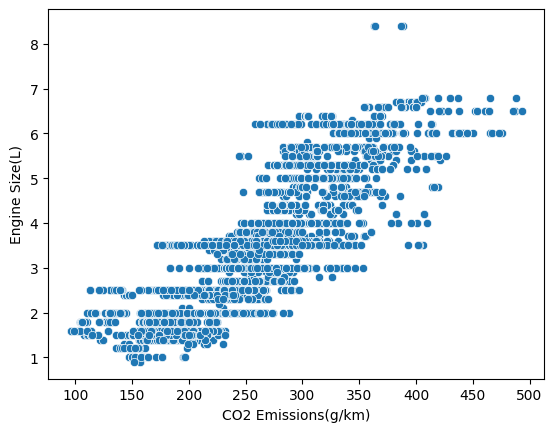

In [20]:
sns.scatterplot(x='CO2 Emissions(g/km)', y='Engine Size(L)', data=df);

In [21]:
df[df['Engine Size(L)'] > 8]

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
945,SRT,VIPER COUPE,TWO-SEATER,8.4,10,M6,Z,16.9,389
946,SRT,VIPER GTS COUPE,TWO-SEATER,8.4,10,M6,Z,16.9,389
1364,DODGE,VIPER SRT COUPE,TWO-SEATER,8.4,10,M6,Z,15.8,363
2337,DODGE,VIPER SRT,TWO-SEATER,8.4,10,M6,Z,15.6,364
3385,DODGE,VIPER,TWO-SEATER,8.4,10,M6,Z,16.6,387


In [22]:
df = df.drop([945, 946, 1364, 2337, 3385])

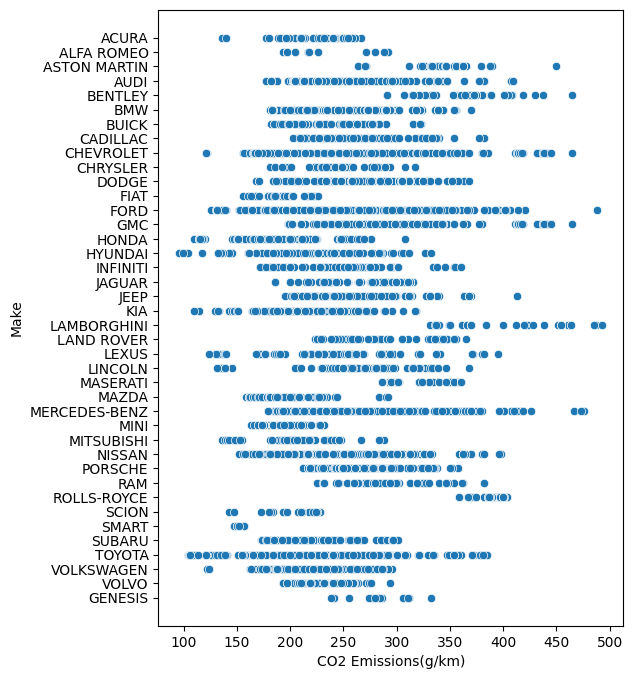

In [23]:
plt.figure(figsize=(6, 8))
sns.scatterplot(x='CO2 Emissions(g/km)', y='Make', data=df);

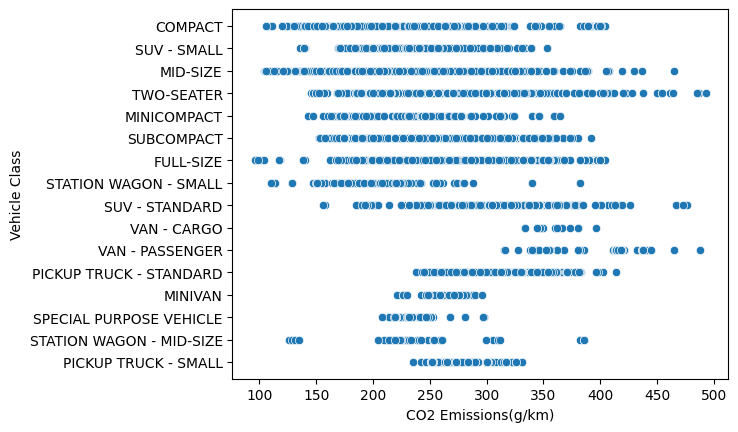

In [24]:
sns.scatterplot(x='CO2 Emissions(g/km)', y='Vehicle Class', data=df);

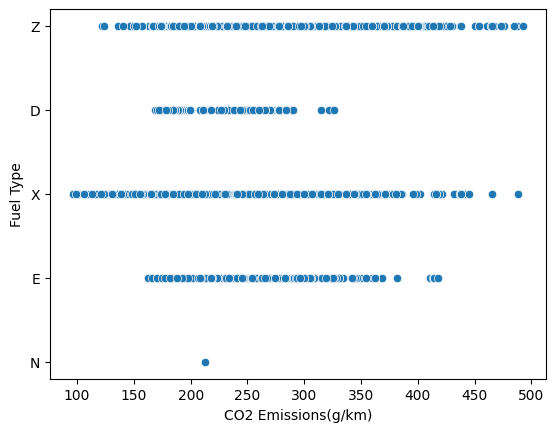

In [25]:
sns.scatterplot(x='CO2 Emissions(g/km)', y='Fuel Type', data=df);

In [26]:
df[df['Fuel Type'] == 'N']

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
2232,CHEVROLET,IMPALA DUAL FUEL,MID-SIZE,3.6,6,AS6,N,12.7,213


In [27]:
df = df.drop(2232)

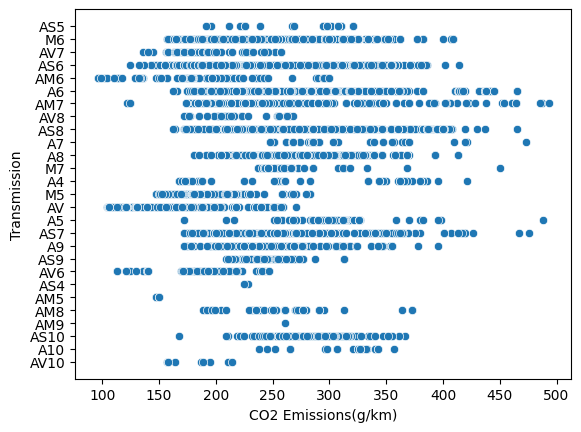

In [28]:
sns.scatterplot(x='CO2 Emissions(g/km)', y='Transmission', data=df);

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import KNNImputer

In [30]:
df = df.reset_index(drop=True)

In [31]:
X = df.drop('CO2 Emissions(g/km)', axis=1)

In [32]:
y = df['CO2 Emissions(g/km)']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [34]:
num_features = X_train.select_dtypes(exclude='object').columns.tolist()
cat_features = X_train.select_dtypes(include='object').columns.tolist()

In [35]:
num_features

['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)']

In [36]:
cat_features

['Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type']

In [37]:
num_transformer = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', num_transformer, num_features)
    ],
    remainder='passthrough'
)

In [39]:
hot_encoder_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler(with_mean=False)),
    ('model', ElasticNetCV(cv=10, l1_ratio=[0.1, 0.5, 1.0], n_jobs=-1, max_iter=100_000))
])

In [40]:
categorical_tranformer = OrdinalEncoder(
    handle_unknown='use_encoded_value', unknown_value=-1
)

In [41]:
preprocessor_2 = ColumnTransformer(
    transformers=[
        ('cat', categorical_tranformer, cat_features),
        ('num', num_transformer, num_features)
    ],
    remainder='passthrough'
)

In [42]:
ordinal_encoder_pipe = Pipeline([
    ('preprocessor', preprocessor_2),
    ('scaler', StandardScaler()),
    ('model', ElasticNetCV(cv=10, l1_ratio=[0.1, 0.5, 1.0], n_jobs=-1, max_iter=100_000))
])

In [43]:
hot_encoder_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

In [44]:
ordinal_encoder_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

In [45]:
y_ordinal_pred = ordinal_encoder_pipe.predict(X_test)
y_train_ordinal_pred = ordinal_encoder_pipe.predict(X_train)
y_encoder_pred = hot_encoder_pipe.predict(X_test)
y_train_encoder_pred = hot_encoder_pipe.predict(X_train)

In [46]:
MAE_ord = mean_absolute_error(y_test, y_ordinal_pred)
MSE_ord = mean_squared_error(y_test, y_ordinal_pred)
RMSE_ord = np.sqrt(MSE_ord)
r2_train_ord = r2_score(y_train, y_train_ordinal_pred)
r2_test_ord = r2_score(y_test, y_ordinal_pred)

In [47]:
MAE_hot = mean_absolute_error(y_test, y_encoder_pred)
MSE_hot = mean_squared_error(y_test, y_encoder_pred)
RMSE_hot = np.sqrt(MSE_hot)
r2_train_hot = r2_score(y_train, y_train_encoder_pred)
r2_test_hot = r2_score(y_test, y_encoder_pred)

In [48]:
print('Ordinal MAE:', MAE_ord)
print('HotEncoder MAE:', MAE_hot)

Ordinal MAE: 10.252930417594293
HotEncoder MAE: 2.8449668449053958


In [49]:
print('Ordinal MSE:', MSE_ord)
print('HotEncoder MSE:', MSE_hot)

Ordinal MSE: 303.80416762093853
HotEncoder MSE: 22.09148801067052


In [50]:
print('Ordinal RMSE:', RMSE_ord)
print('HotEncoder RMSE:', RMSE_hot)

Ordinal RMSE: 17.429978990834687
HotEncoder RMSE: 4.700158296341786


In [51]:
print('Ordinal R2_train:', r2_train_ord)
print('HotEncoder R2_train:', r2_train_hot)

Ordinal R2_train: 0.9280637570248015
HotEncoder R2_train: 0.9968272900796229


In [52]:
print('Ordinal R2_test:', r2_test_ord)
print('HotEncoder R2_test:', r2_test_hot)

Ordinal R2_test: 0.9124108478027754
HotEncoder R2_test: 0.9936308487115816


In [53]:
df['CO2 Emissions(g/km)'].mean()

np.float64(250.99569583931134)

In [54]:
pipe = hot_encoder_pipe

In [55]:
best_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_model.l1_ratio_}")

Лучшее значение alpha: 0.05436665225679535
Лучшее значение l1_ratio: 1.0


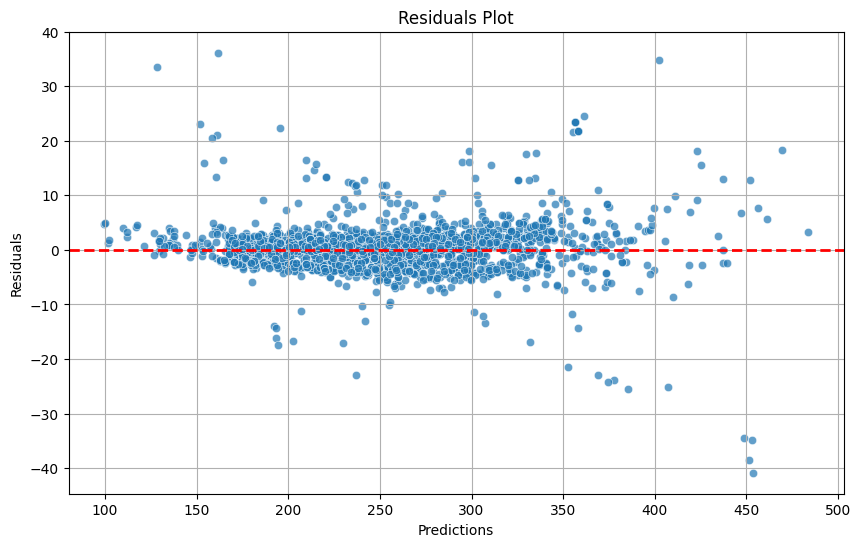

In [56]:
residuals = y_test - y_encoder_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_encoder_pred, y=residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)

plt.title('Residuals Plot')
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.grid(True)

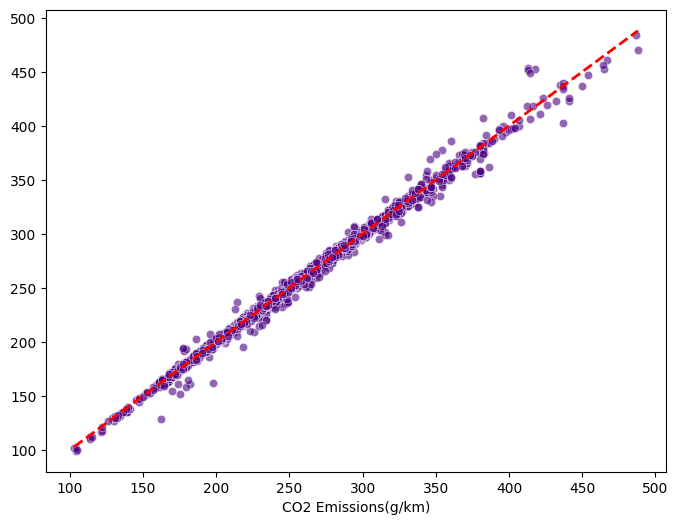

In [57]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=y_encoder_pred, alpha=0.6, color='indigo')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2);

In [58]:
pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

In [59]:
y_pred_full = pipe.predict(X)

In [60]:
best_final_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_final_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_final_model.l1_ratio_}")

Лучшее значение alpha: 0.054089036091249265
Лучшее значение l1_ratio: 1.0


In [61]:
r2_full = r2_score(y, y_pred_full)

In [62]:
r2_full

0.9966227064151278

In [63]:
df[df['Make'] == 'SMART']['Model']

943     FORTWO CABRIOLET
944         FORTWO COUPE
1874    FORTWO CABRIOLET
1875        FORTWO COUPE
2974    FORTWO CABRIOLET
2975        FORTWO COUPE
3976    FORTWO CABRIOLET
Name: Model, dtype: object

In [64]:
test_df = pd.DataFrame(
    {
        "Make": ["LAMBORGHINI", "SMART"],
        "Model": ["AVENTADOR S COUPE", "FORTWO COUPE"],
        "Vehicle Class": ["TWO-SEATER", "TWO-SEATER"],
        "Engine Size(L)": [6.5, 0.9],
        "Cylinders": [12, 3],
        "Transmission": ["AM7", "AM6"],
        "Fuel Type": ["Z", "Z"],
        "Fuel Consumption Comb (L/100 km)": [18.0, 5.9],
    }
)

co2_predictions = pipe.predict(test_df)

for i, car in test_df.iterrows():
    print(
        f"🚗 {car['Make']} {car['Model']} (V{int(car['Cylinders'])}, {car['Engine Size(L)']}L) "
        f"расход: {car['Fuel Consumption Comb (L/100 km)']} л/100км "
        f"➡️ Прогноз выбросов CO2: {co2_predictions[i]:.2f} г/км"
    )

🚗 LAMBORGHINI AVENTADOR S COUPE (V12, 6.5L) расход: 18.0 л/100км ➡️ Прогноз выбросов CO2: 424.48 г/км
🚗 SMART FORTWO COUPE (V3, 0.9L) расход: 5.9 л/100км ➡️ Прогноз выбросов CO2: 134.81 г/км


In [65]:
import json
import os

advanced_report = {
    "project": "CO2 Emissions Vehicle Data",
    "model": "ElasticNetCV",
    "trained_date": '2026-07',
    "test_parameters": {
        "alpha": best_model.alpha_,
        "l1_ratio": best_model.l1_ratio_,
        "cv": best_model.cv
    },
    "final_parameters": {
        "alpha": best_final_model.alpha_,
        "l1_ratio":  best_final_model.l1_ratio_,
        "cv": best_final_model.cv
    },
    "metrics": {
        "RMSE": RMSE_hot,
        "MAE": MAE_hot,
        "R2_train": r2_train_hot,
        "R2_test": r2_test_hot,
        "R2_full": r2_full,
        "Mean_CO2_Emmisions": df['CO2 Emissions(g/km)'].mean()
    }
}


filename = "model_description.json"

with open(filename, "w", encoding="utf-8") as f:
    json.dump(advanced_report, f, indent=4, ensure_ascii=False)

In [66]:
from joblib import dump, load

In [67]:
dump(pipe, 'model/co2_emissions_predict_elastic_net_cv_2026_v1.pkl')

['model/co2_emissions_predict_elastic_net_cv_2026_v1.pkl']

In [68]:
loaded_pipe = load('model/co2_emissions_predict_elastic_net_cv_2026_v1.pkl')

In [69]:
loaded_pipe.predict(test_df)

array([424.47597907, 134.81230706])